# Visualização de Focus de Modelos

### Notebook para Carregar e Visualizar, Via Mapas de Calor, o Foco dos Modelos nas Imagens

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def _resolve_project_root():
    """Sobe diretórios até encontrar utils/models_to_pkl.py."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "utils" / "models_to_pkl.py").is_file():
            return str(base)
    raise FileNotFoundError("Raiz do repositório não encontrada (esperado utils/models_to_pkl.py).")


project_root = _resolve_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.gradcam import find_last_spatial_layer_name, make_gradcam_heatmap, overlay_jet_on_rgb
from utils.models_to_pkl import load_model
from utils.tf_gpu import configure_gpu_memory_growth, log_gpu_status

configure_gpu_memory_growth()
log_gpu_status()

from utils.visualization_samples import (
    format_probs_percent,
    list_val_npy_images,
    predicted_class,
    shuffle_samples,
)


I0000 00:00:1779199191.248682  133979 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



TensorFlow devices
  GPU count: 1
  [0] /physical_device:GPU:0
  CPU count: 1



I0000 00:00:1779199196.817743  133979 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 752 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [2]:
VAL_NPY_ROOT = os.path.join(
    project_root,
    "data",
    "CO2Wounds-V2",
    "processed",
    "train_images_binary",
    "val",
)
SHUFFLE_SEED = 42
MAX_IMAGES = None


## Modelo treinado do zero em canal Y (`.npy`): entrada `(1, 224, 224, 1)` — **sem** pesos ImageNet


In [3]:
def get_img_array(img_path):
    """Arrays .npy do pipeline estão em [0,1] (float), como no treino."""
    img = np.load(img_path)
    if img.ndim == 2:
        img = img[..., np.newaxis]
    img = tf.image.resize(img.astype(np.float32), (224, 224)).numpy()
    return tf.constant(np.expand_dims(img, axis=0), dtype=tf.float32)


def _npy_to_display_rgb(img_path):
    arr = np.load(img_path)
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = cv2.resize(arr, (224, 224))
    if arr.max() <= 1.0:
        v = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    else:
        v = np.clip(arr, 0, 255).astype(np.uint8)
    return np.stack([v, v, v], axis=-1)


def display_gradcam(img_path, heatmap, true_class, pred_class, probs, alpha=0.5, gamma=2.0, percentile=80):
    rgb = _npy_to_display_rgb(img_path)
    overlay = overlay_jet_on_rgb(rgb, heatmap, alpha=alpha, gamma=gamma, percentile=percentile)
    plt.figure(figsize=(12, 6))
    plt.suptitle(
        f"Classe real: {true_class} | Classe prevista: {pred_class}\n{format_probs_percent(probs)}",
        fontsize=11,
    )
    plt.subplot(1, 2, 1)
    plt.title("Canal Y (visualização)")
    plt.imshow(rgb)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


_fromzero_base = os.environ.get(
    "CO2WOUNDS_FROMZERO_MODEL", "modelo_binario_co2wounds_fromzero_processed"
)
model_path = os.path.join(project_root, "models", _fromzero_base)
model = load_model(model_path)


✅ Modelo carregado de: /home/alyssandro/Documentos/Github/leprosy_classification_models-TCC/models/modelo_binario_co2wounds_fromzero_processed.keras


Grad-CAM usando camada: conv5_block3_out
Processando 718 imagem(ns) de val (leprosy + outros), embaralhadas.


I0000 00:00:1779199206.980922  134308 service.cc:153] XLA service 0x7a4b7806c810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779199206.980982  134308 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.2.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779199207.121765  134308 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779199208.488965  134308 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1779199220.432913  134308 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.07GiB (rounded to 1145307648)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1779199220.433001  134308

warts-common-1 — real: outros | prevista: outros


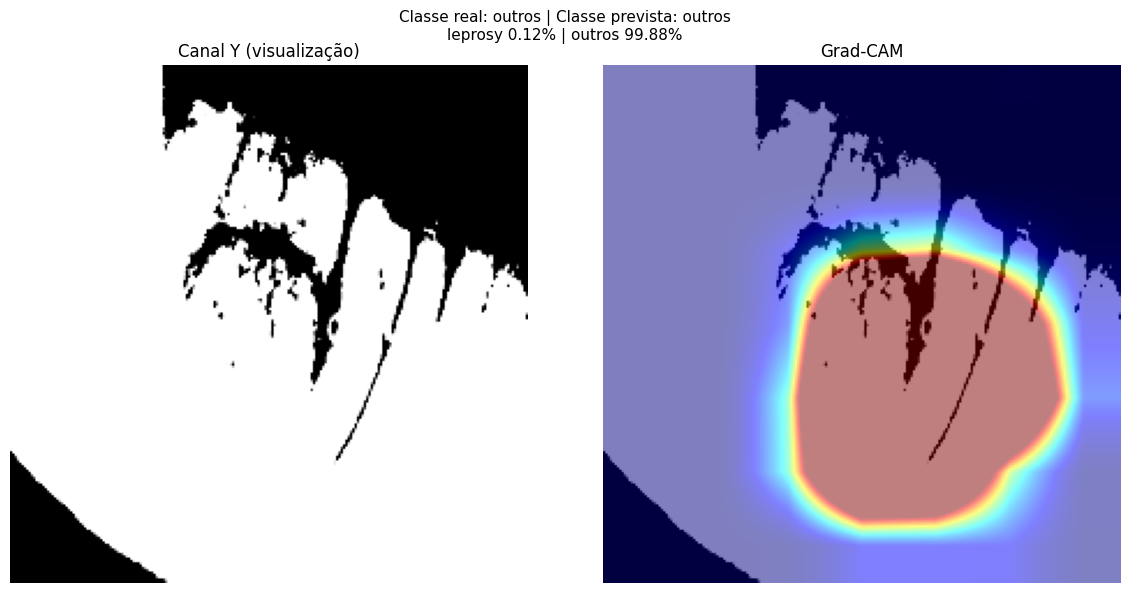

eczema-herpeticum-27 — real: outros | prevista: outros


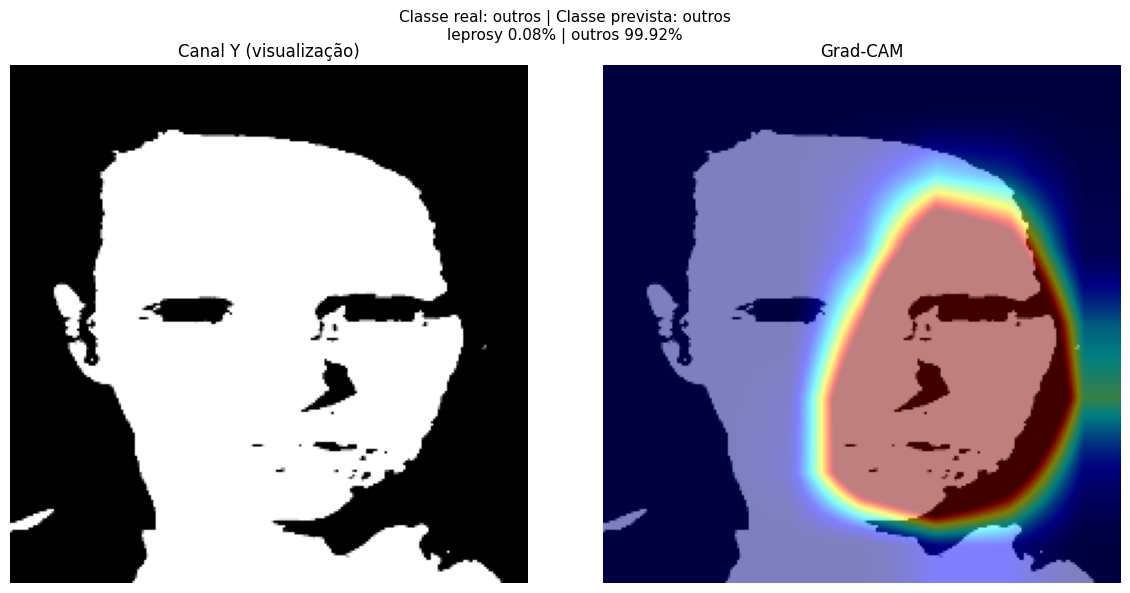

warts-common-56 — real: outros | prevista: outros


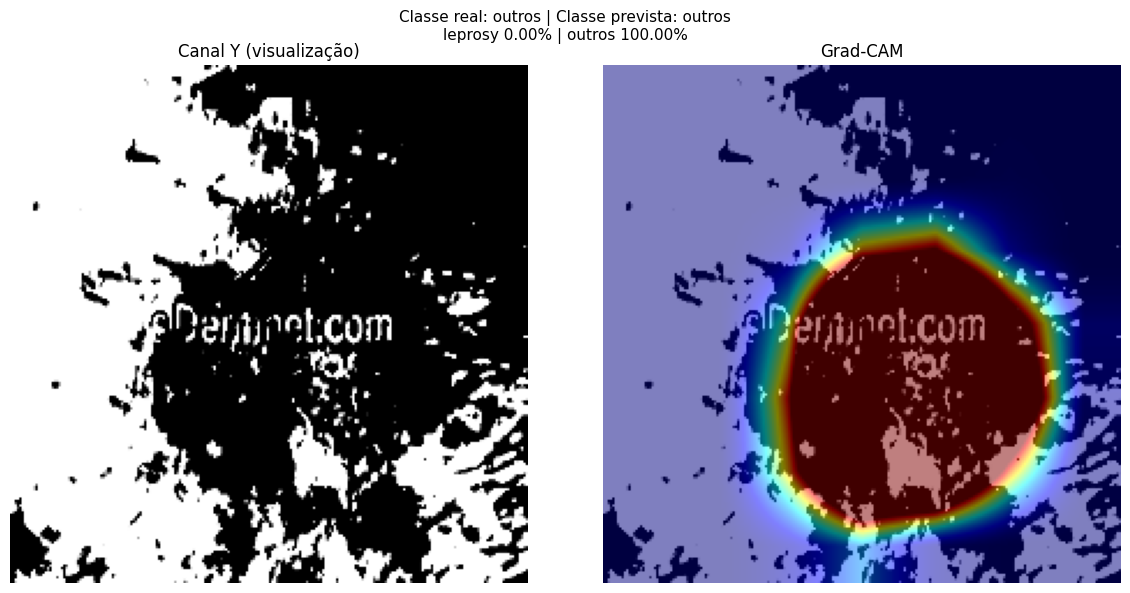

fixed-drug-eruption-22 — real: outros | prevista: outros


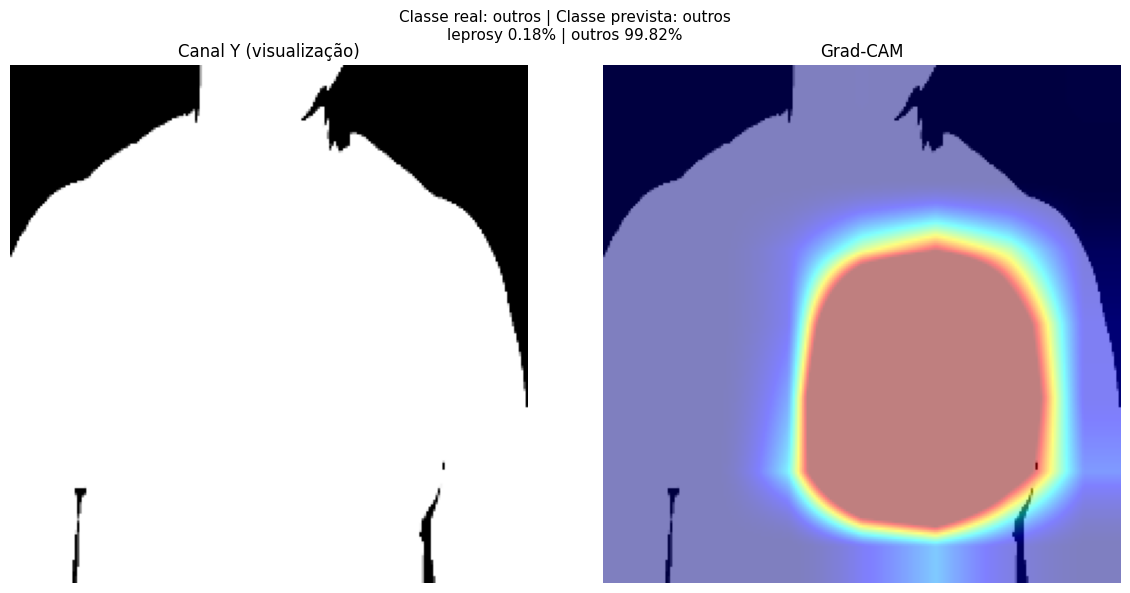

milia-14 — real: outros | prevista: outros


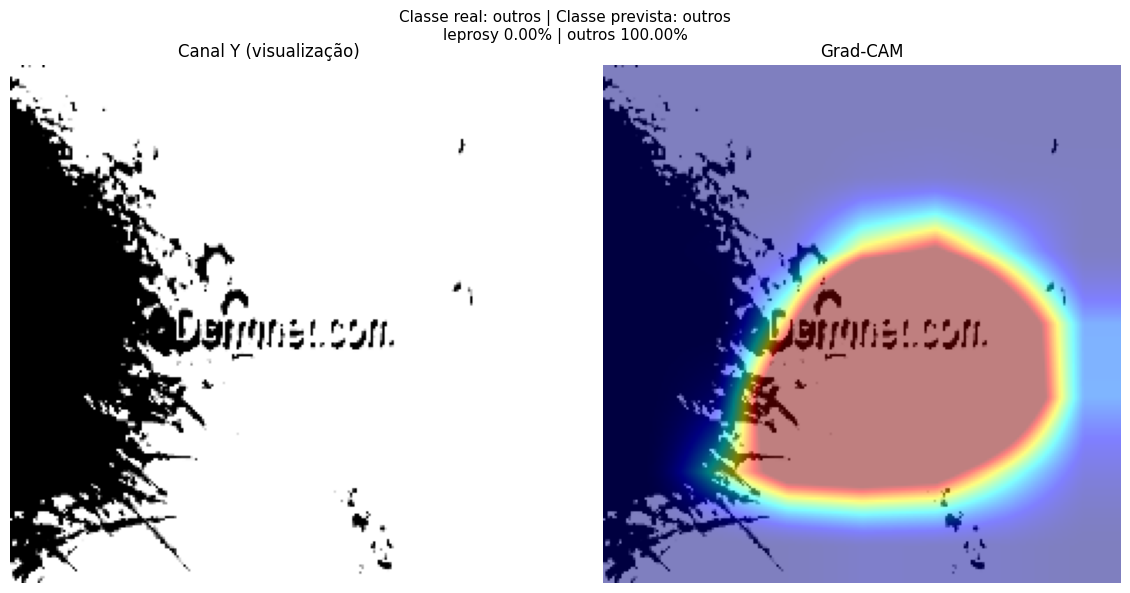

enterovirus-21 — real: outros | prevista: outros


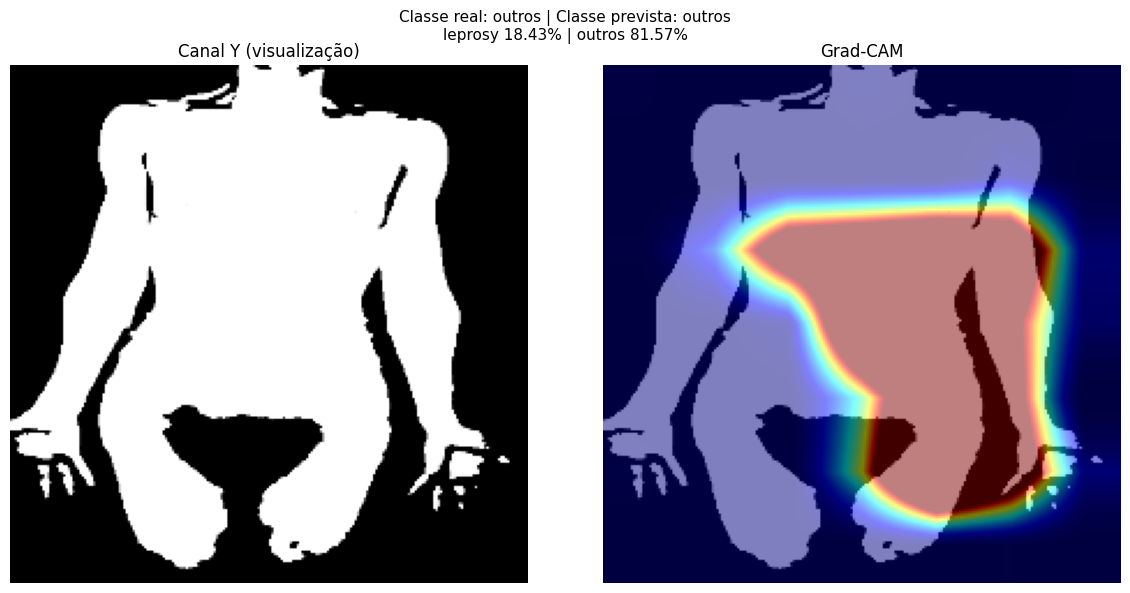

eczema-acute-5 — real: outros | prevista: outros


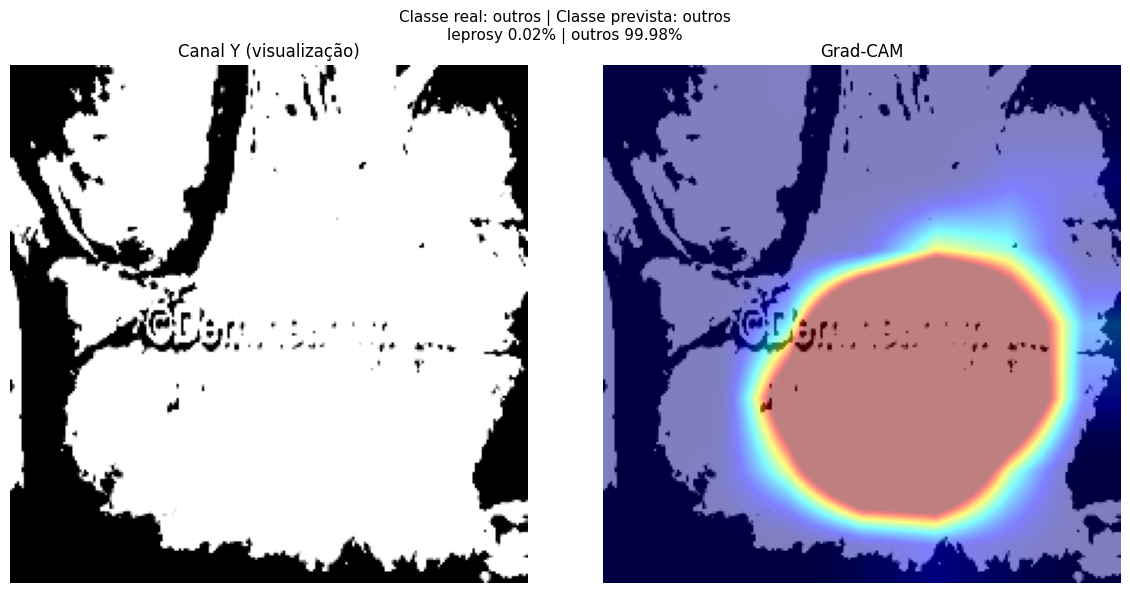

chronic-paronychia-41 — real: outros | prevista: outros


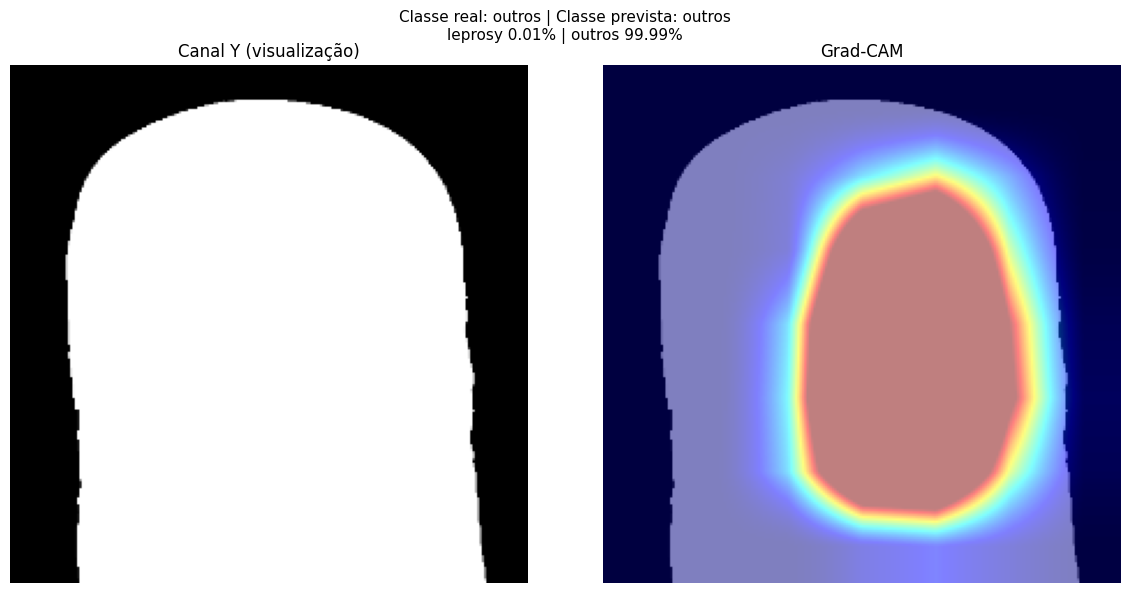

eczema-nummular-133 — real: outros | prevista: outros


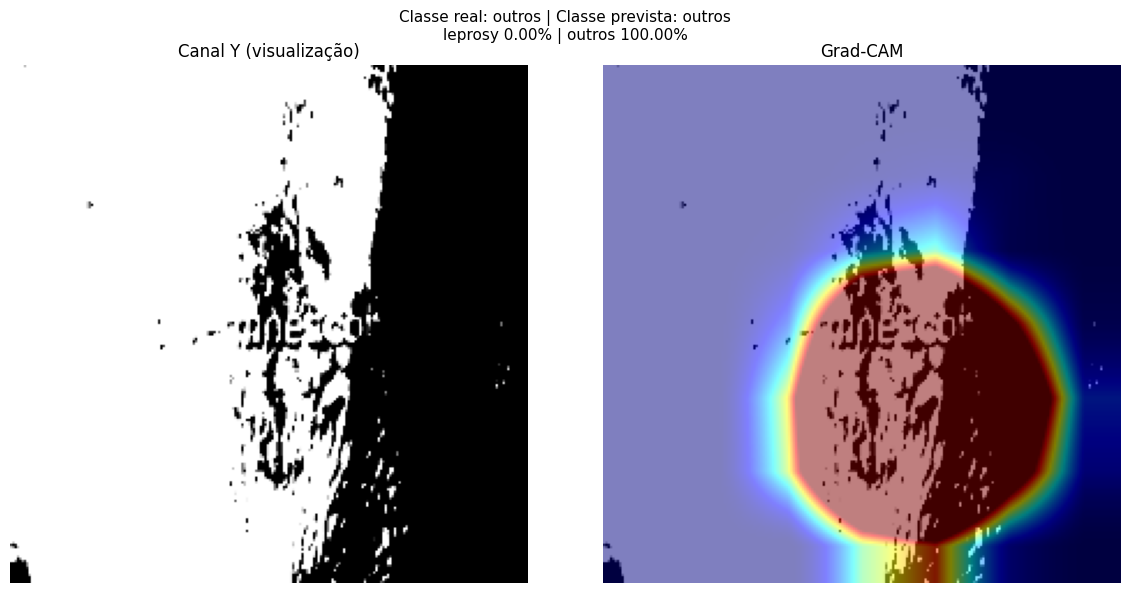

lupus-acute-40 — real: outros | prevista: outros


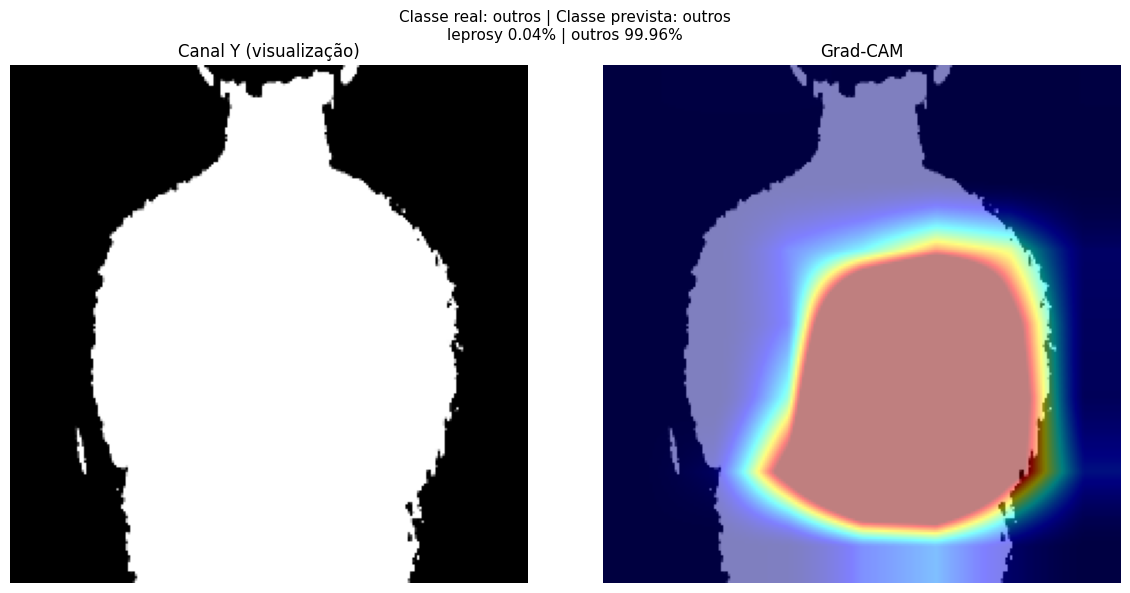

IMG1312 — real: leprosy | prevista: leprosy


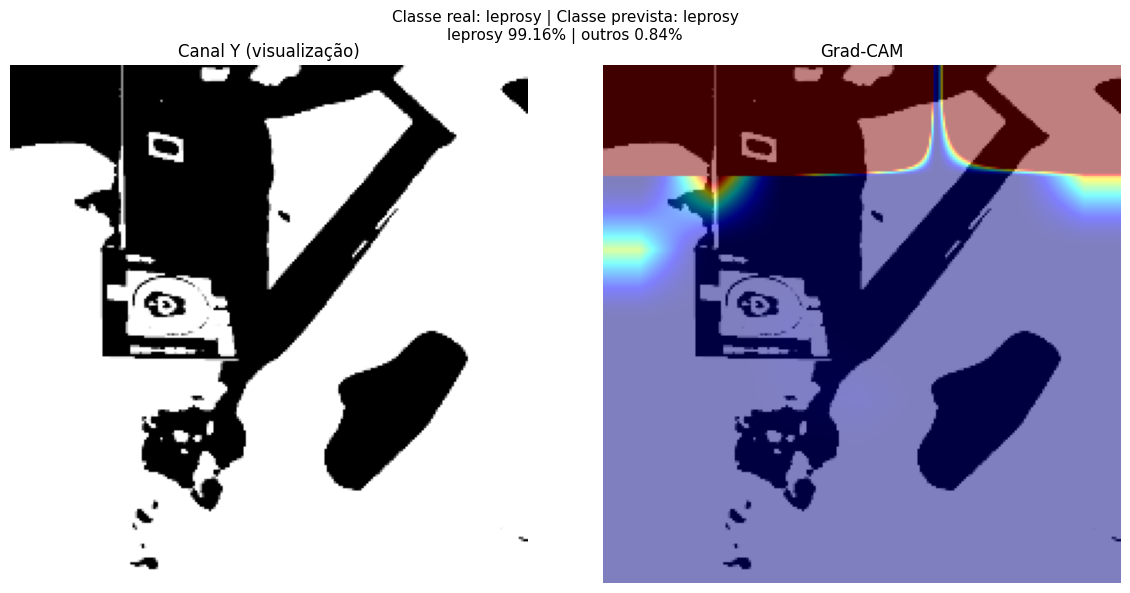

actinic-keratosis-horn-6 — real: outros | prevista: outros


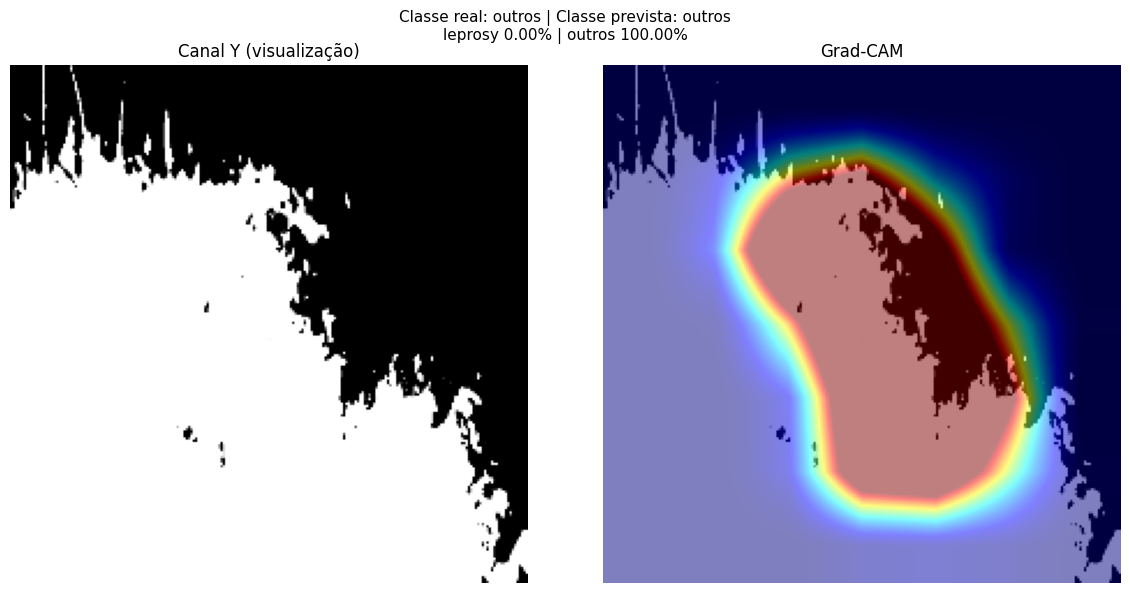

hidradenitis-suppurativa-29 — real: outros | prevista: outros


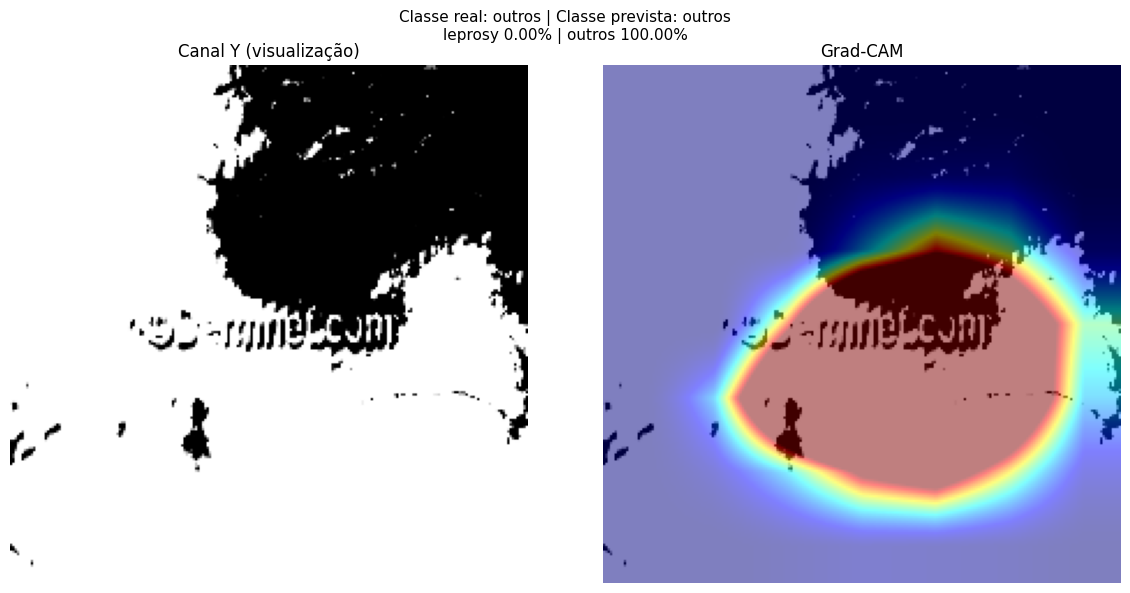

psoriasis-palms-soles-185 — real: outros | prevista: outros


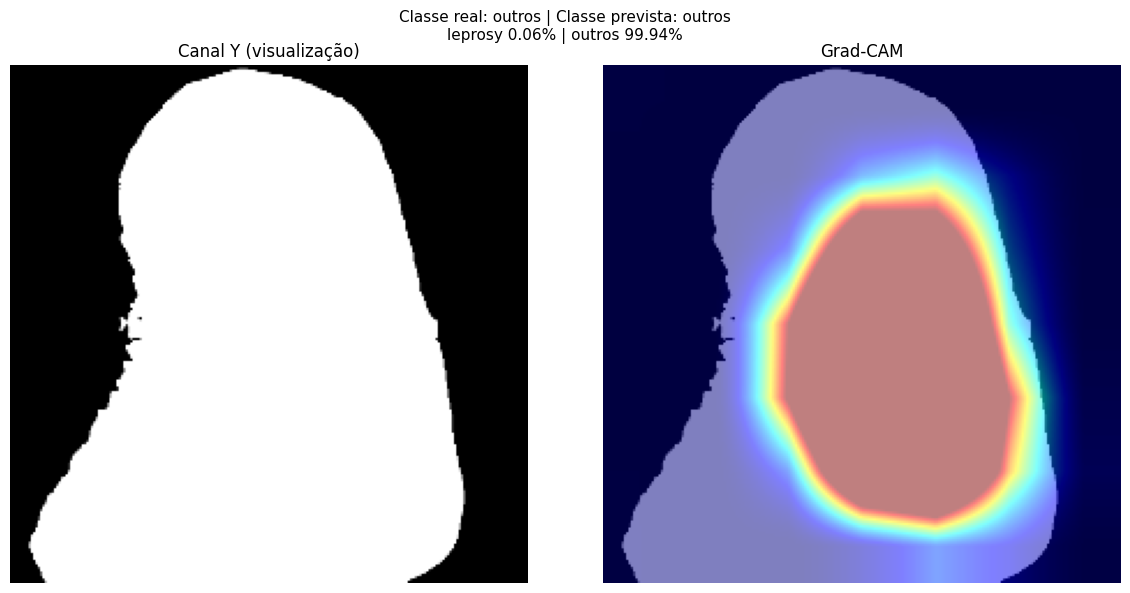

IMG1617 — real: leprosy | prevista: outros


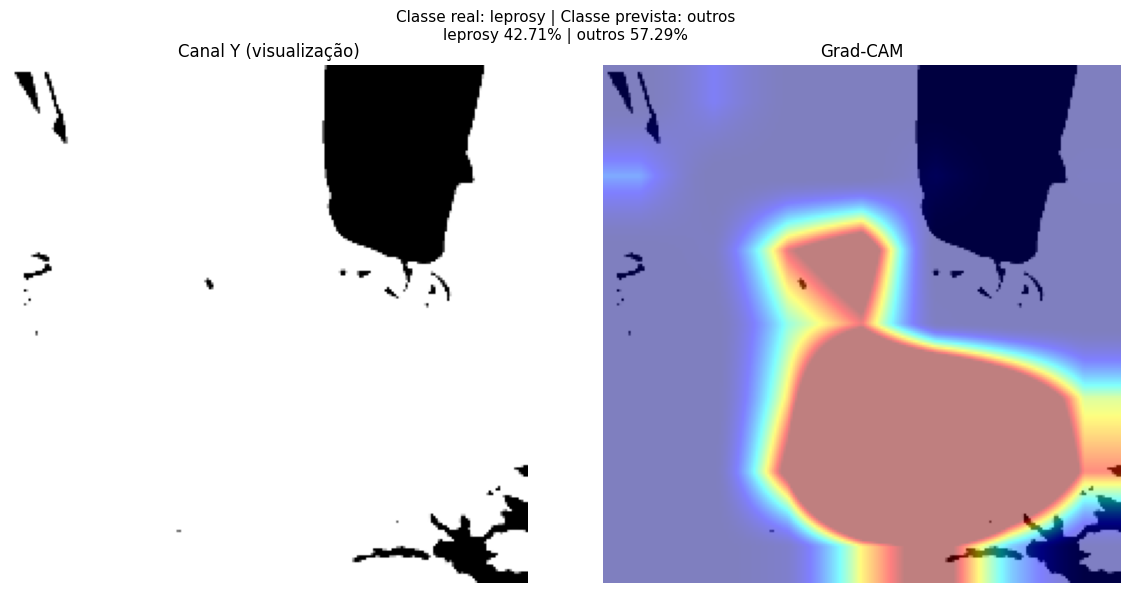

cytomegalovirus-1 — real: outros | prevista: outros


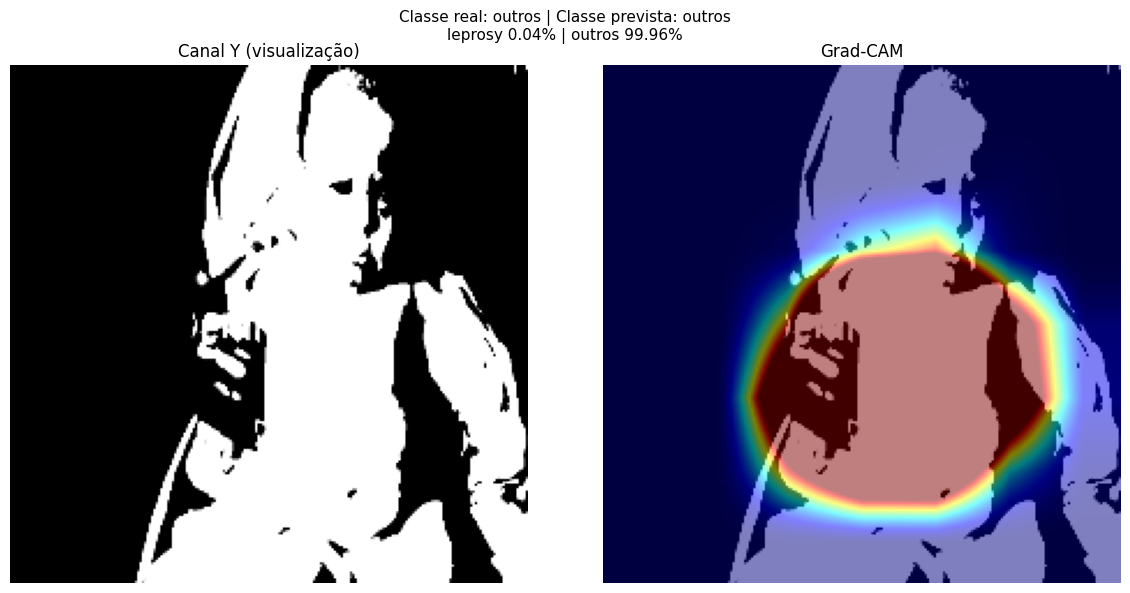

venous-lake-44 — real: outros | prevista: outros


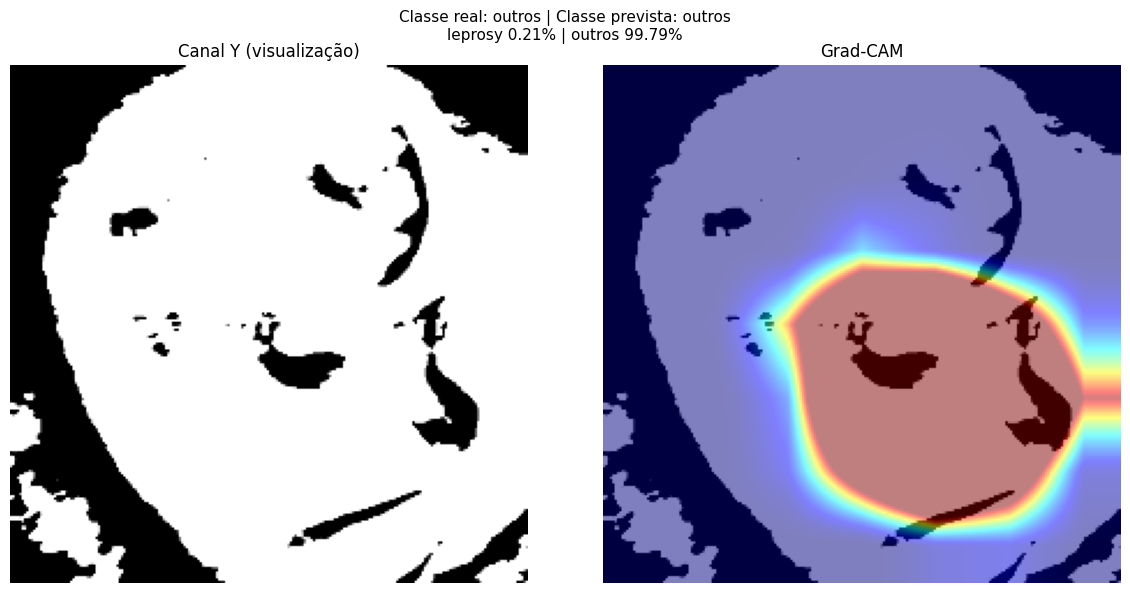

drug-eruptions-76 — real: outros | prevista: outros


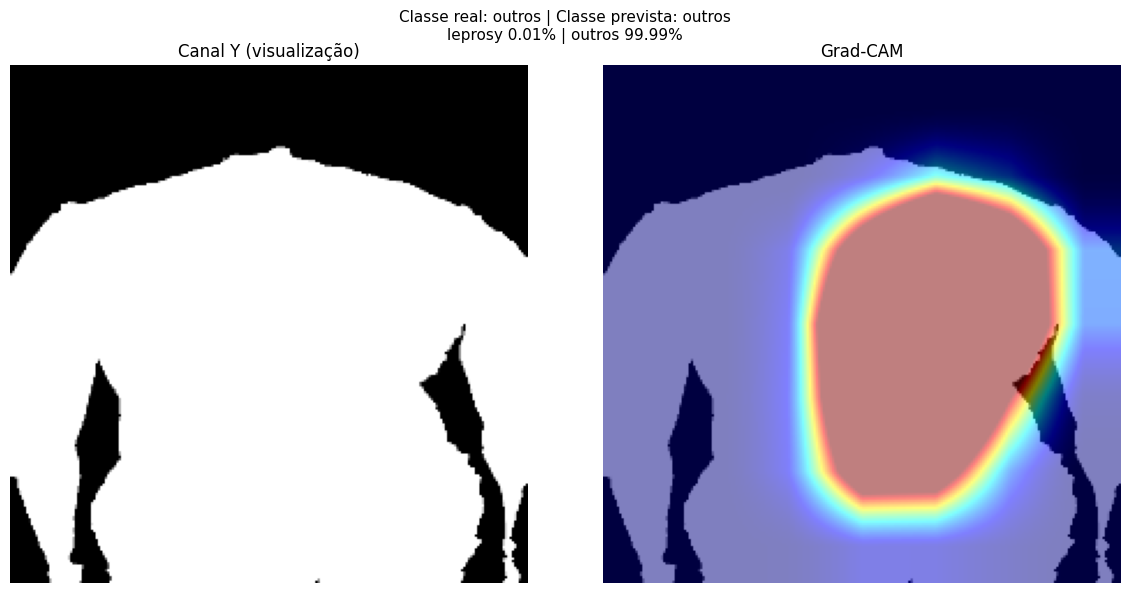

tinea-palm-7 — real: outros | prevista: outros


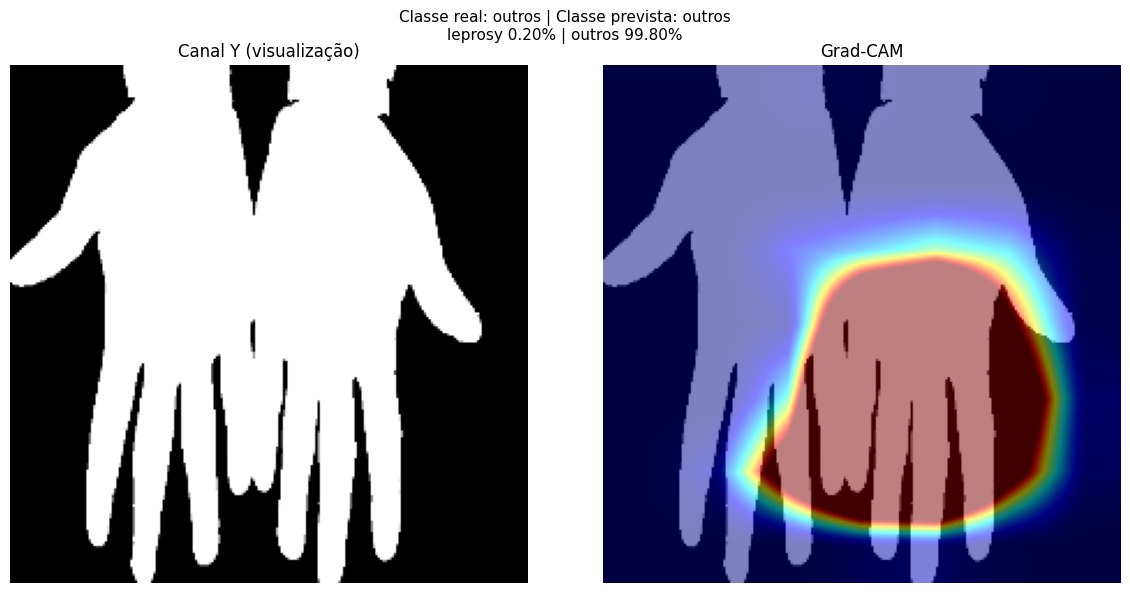

squamous-cell-carcinoma-lesion-24 — real: outros | prevista: outros


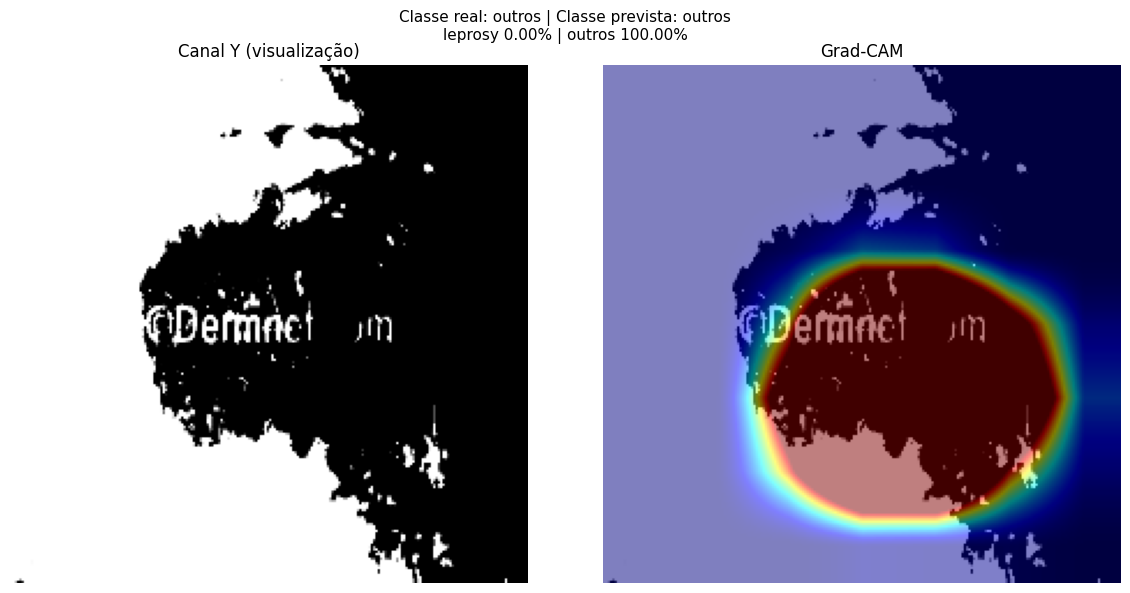

pretibial-myxedema-16 — real: outros | prevista: outros


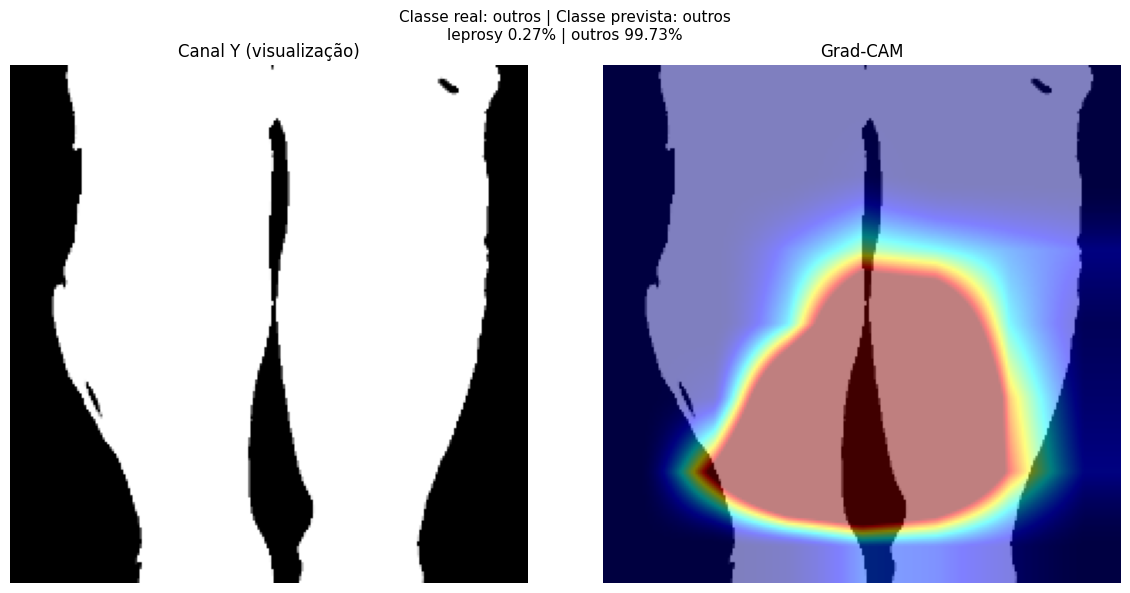

actinic-keratosis-lesion-52 — real: outros | prevista: outros


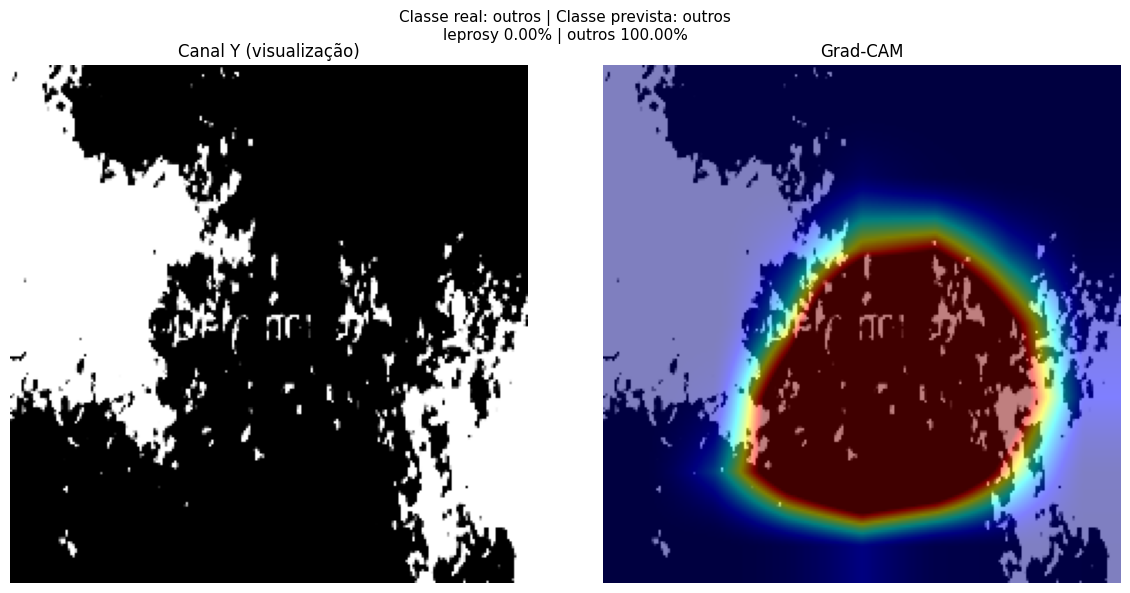

genital-warts-23 — real: outros | prevista: outros


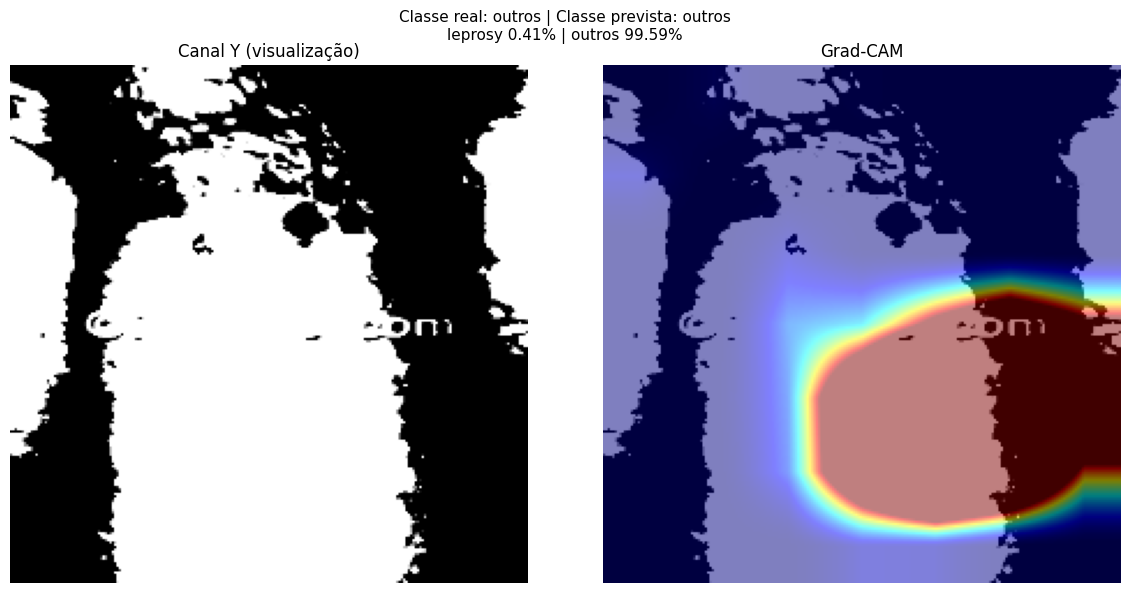

habit-tic-deformity-7 — real: outros | prevista: outros


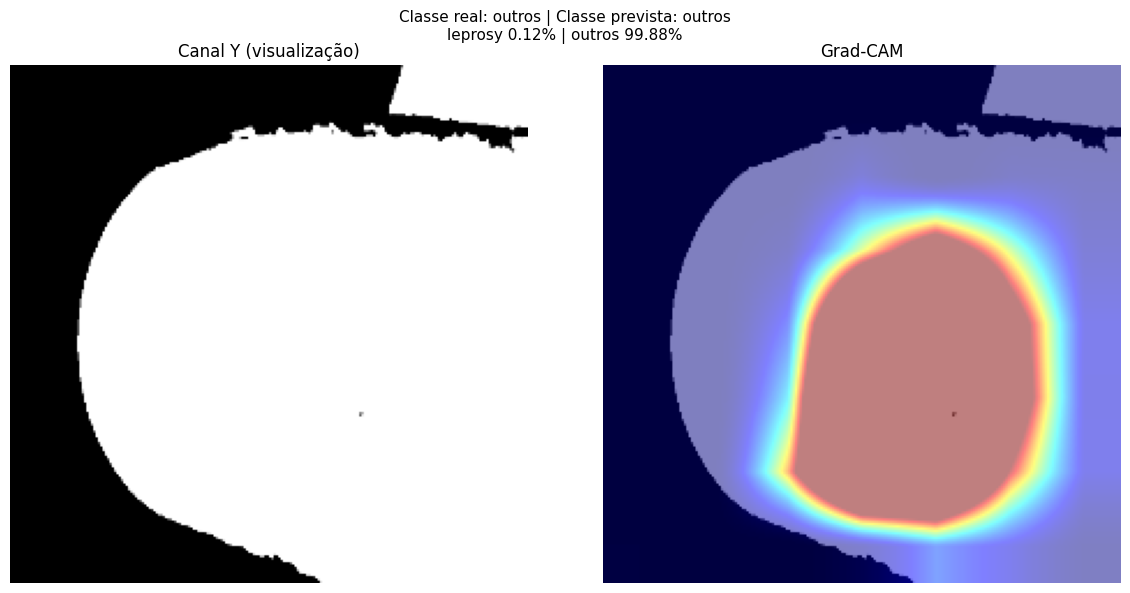

rhus-dermatitis-35 — real: outros | prevista: outros


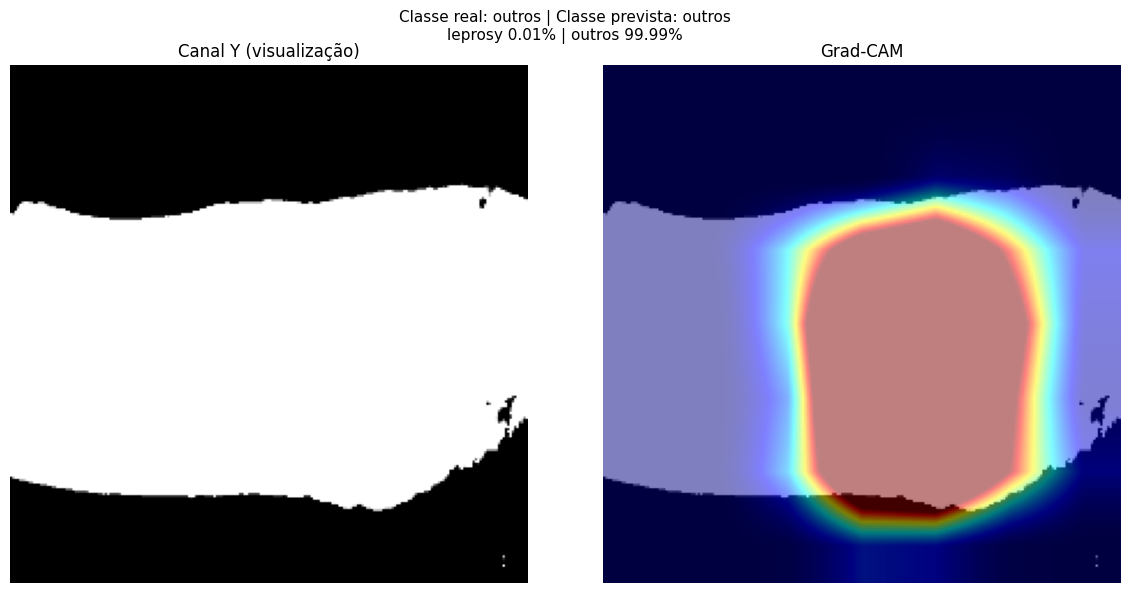

eczema-nummular-127 — real: outros | prevista: outros


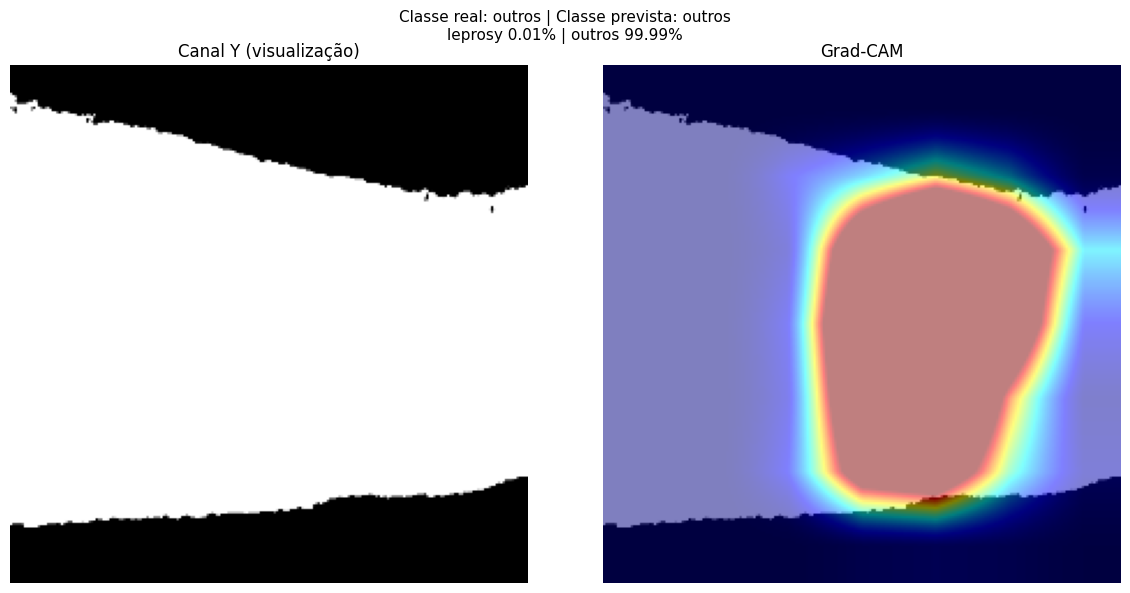

IMG1368 — real: leprosy | prevista: leprosy


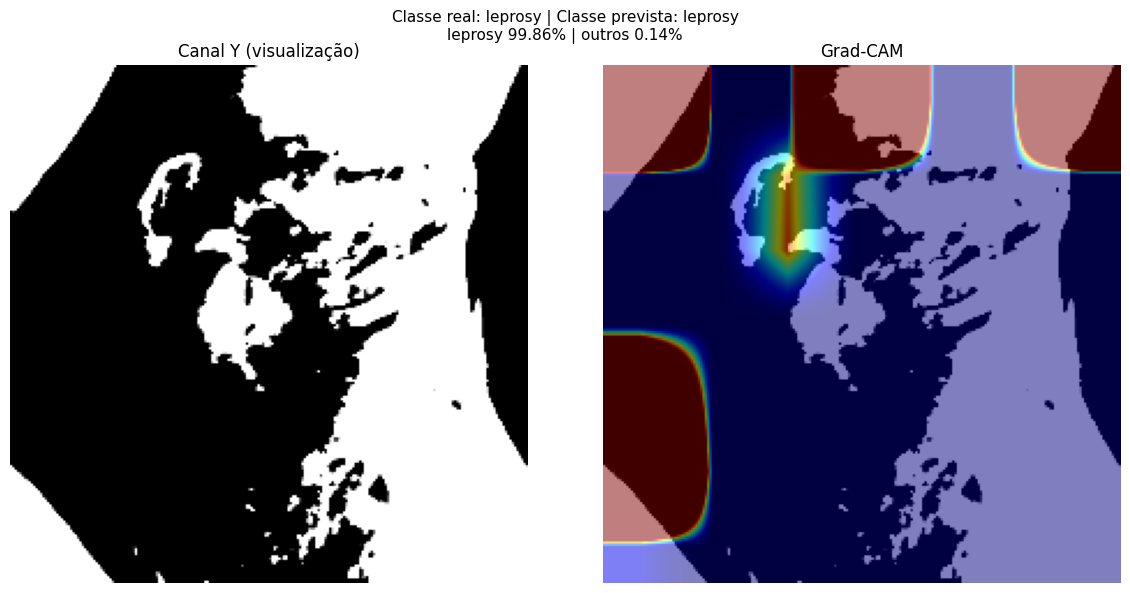

sun-damaged-skin-80 — real: outros | prevista: outros


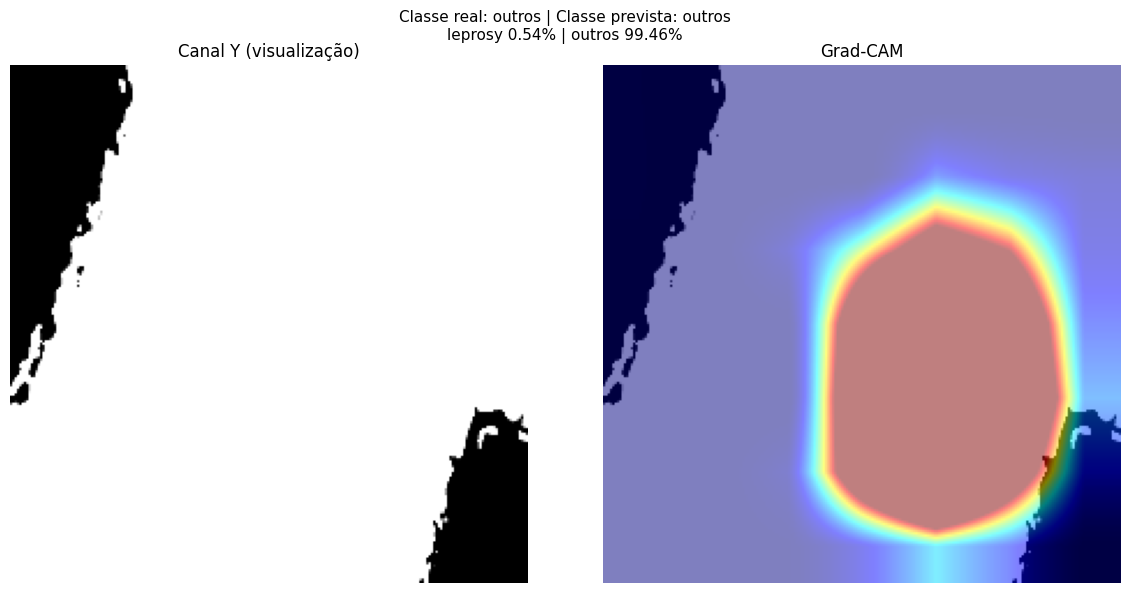

IMG683 — real: leprosy | prevista: leprosy


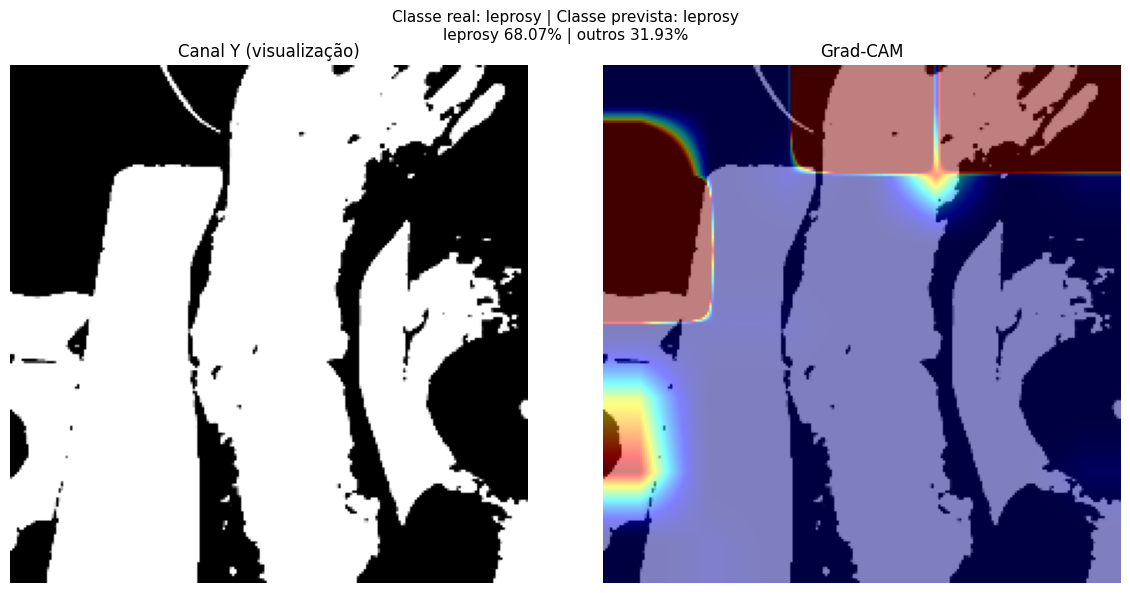

eczema-foot-56 — real: outros | prevista: outros


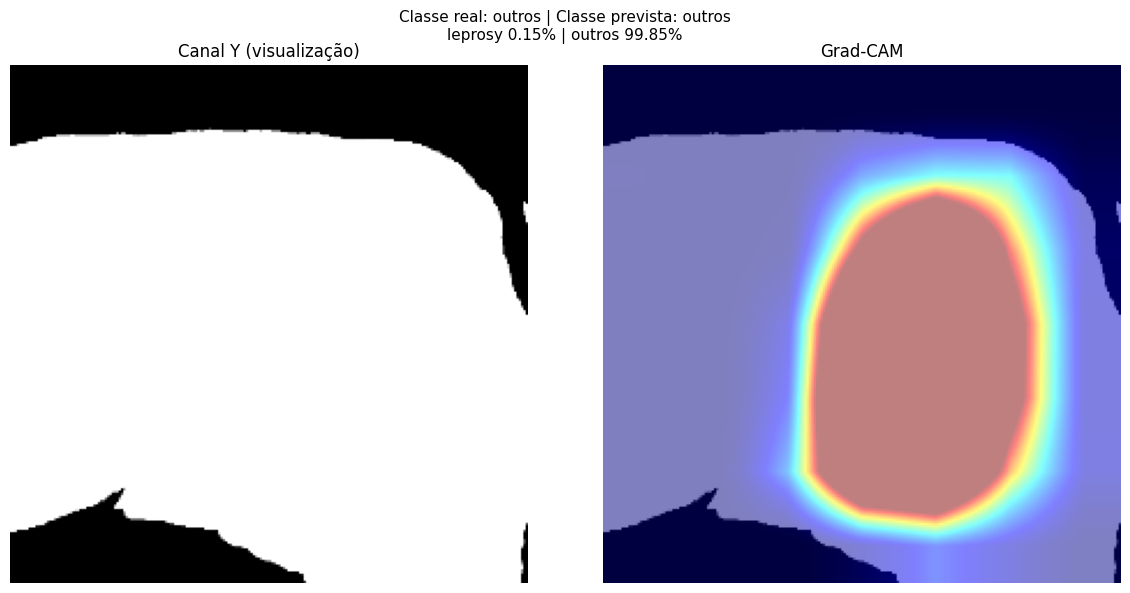

metastasis-11 — real: outros | prevista: outros


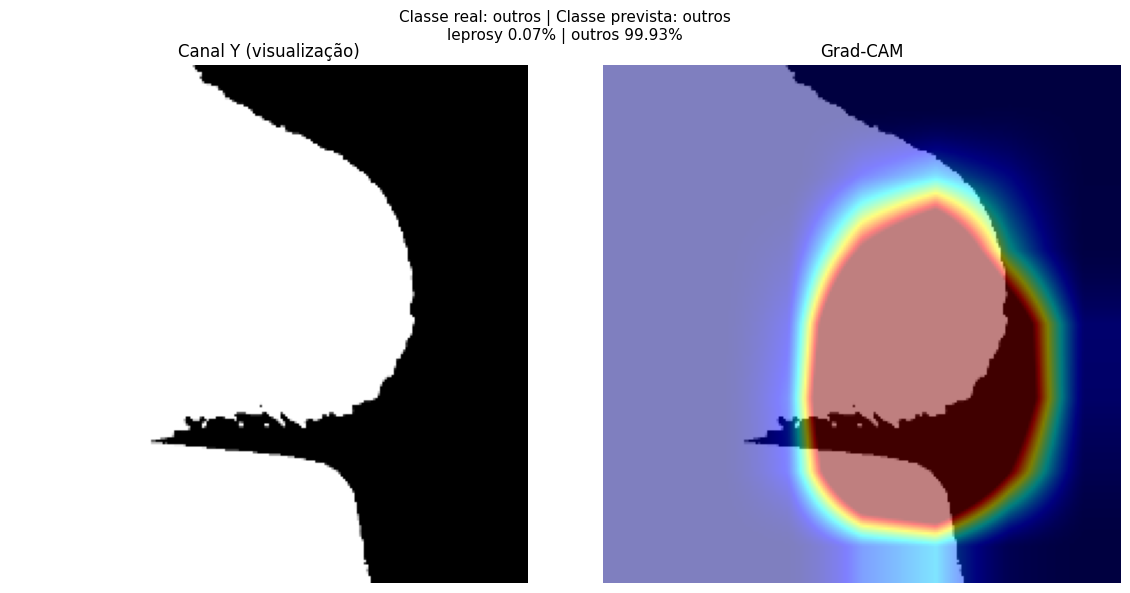

IMG1285 — real: leprosy | prevista: leprosy


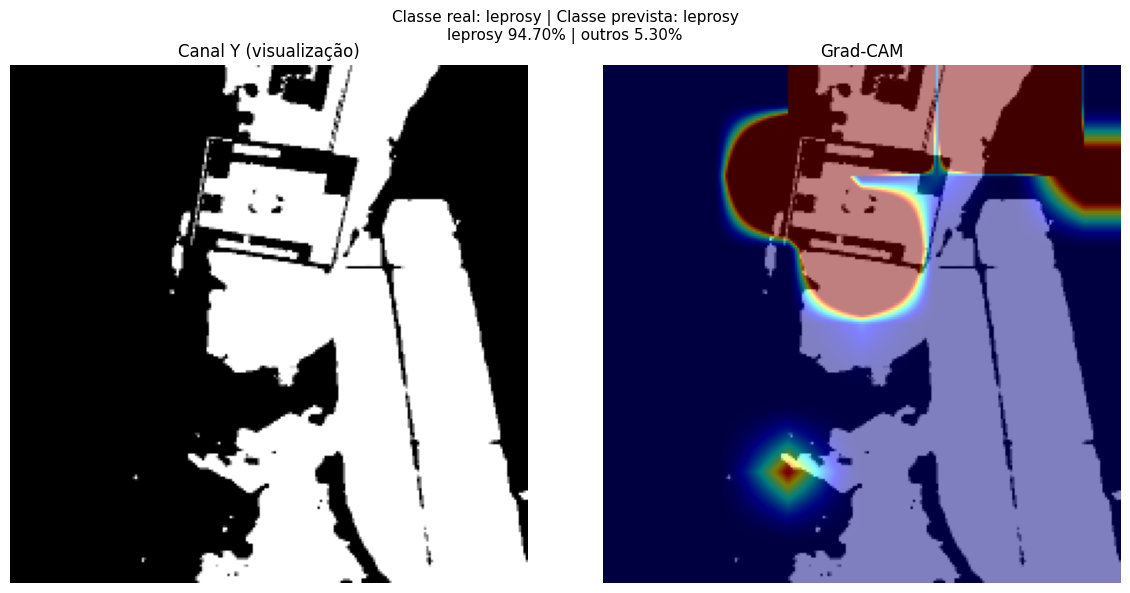

Psoriasis-Guttate-6 — real: outros | prevista: outros


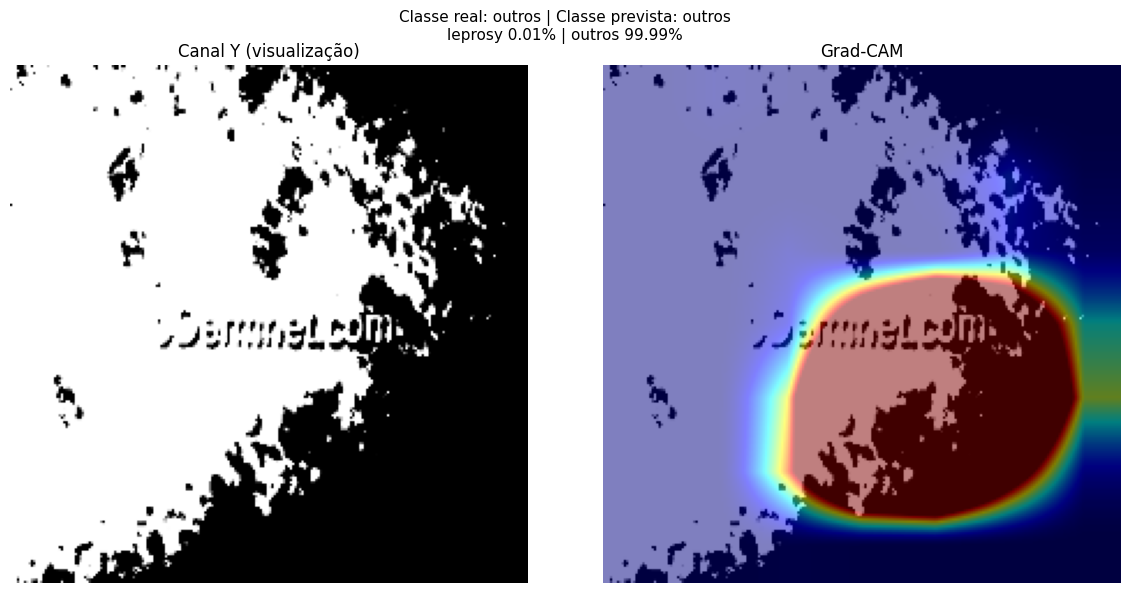

venous-lake-28 — real: outros | prevista: outros


KeyboardInterrupt: 

In [4]:
LAST_CONV = find_last_spatial_layer_name(model)
print("Grad-CAM usando camada:", LAST_CONV)

samples = list_val_npy_images(VAL_NPY_ROOT)
if not samples:
    raise FileNotFoundError(f"Nenhum .npy em {VAL_NPY_ROOT}/leprosy ou .../outros")

samples = shuffle_samples(samples, seed=SHUFFLE_SEED)
if MAX_IMAGES is not None:
    samples = samples[: int(MAX_IMAGES)]

print(f"Processando {len(samples)} imagem(ns) de val (leprosy + outros), embaralhadas.")

for stem, img_path, true_class in samples:
    img_array = get_img_array(img_path)
    probs = model.predict(img_array, verbose=0)[0]
    pred_class = predicted_class(probs)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name=LAST_CONV)
    print(f"{stem} — real: {true_class} | prevista: {pred_class}")
    display_gradcam(img_path, heatmap, true_class, pred_class, probs)


In [ ]:
# Exemplo único (opcional): descomente e ajuste o stem
# stem = "IMG558"
# for class_name in ("leprosy", "outros"):
#     img_path = os.path.join(VAL_NPY_ROOT, class_name, f"{stem}.npy")
#     if os.path.isfile(img_path):
#         ...
print("Use a célula anterior para percorrer todo o val embaralhado.")
